In [13]:
from dataclasses import dataclass
import random
from dataclasses import dataclass
from collections import defaultdict

W_SIZE = 1000
INF = 10**18

In [14]:
@dataclass
class Rect:
    x1: int
    y1: int
    x2: int
    y2: int

    def calc_area(self):
        return (self.x2 - self.x1) * (self.y2 - self.y1)

In [15]:
def overlap_1d(xl1: int, xr1: int, xl2: int, xr2: int):
    return True if max(xl1, xl2) < min(xr1, xr2) else False


def overlap_1d_ok_just(xl1: int, xr1: int, xl2: int, xr2: int):
    return True if max(xl1, xl2) <= min(xr1, xr2) else False


def overlap_1d_vec_ok_just(vec1: tuple[int, int], vec2: tuple[int, int]):
    return overlap_1d_ok_just(vec1[0], vec1[1], vec2[0], vec2[1])


def overlap_1d_vec(vec1: tuple[int, int], vec2: tuple[int, int]):
    return overlap_1d(vec1[0], vec1[1], vec2[0], vec2[1])


def get_overlap_vec(vec1: tuple[int, int], vec2: tuple[int, int]):
    return (max(vec1[0], vec2[0]), min(vec1[1], vec2[1]))


def concat_1d_vec(vecs: list[tuple[int, int]]) -> list[tuple[int, int]]:
    serched_vecs = []
    for vec in vecs:
        overlap_vecs = [vec]
        non_overlap_vecs = []
        for seached_vec in serched_vecs:
            if overlap_1d_vec_ok_just(vec, seached_vec):
                overlap_vecs.append(seached_vec)
            else:
                non_overlap_vecs.append(seached_vec)
        concat_overlap_vec = (min([v[0] for v in overlap_vecs]), max([v[1] for v in overlap_vecs]))
        serched_vecs = non_overlap_vecs + [concat_overlap_vec]
    return serched_vecs


def evaluate_1d_partition_costs(pre_vecs: list[tuple[int, int]], next_vecs: list[tuple[int, int]]) -> int:
    pre_vecs = concat_1d_vec(pre_vecs)
    next_vecs = concat_1d_vec(next_vecs)

    overlaped_vecs = []
    for pre_vec in pre_vecs:
        for next_vec in next_vecs:
            if overlap_1d_vec(pre_vec, next_vec):
                overlaped_vecs.append(get_overlap_vec(pre_vec, next_vec))

    cost = 0
    cost += sum(vec[1] - vec[0] for vec in pre_vecs)
    cost += sum(vec[1] - vec[0] for vec in next_vecs)

    converged_overlaped_vecs = concat_1d_vec(overlaped_vecs)
    for vec in converged_overlaped_vecs:
        cost -= (vec[1] - vec[0]) * 2
    return cost


def evaluate_partition_rect_cost(pre_rect: list[Rect], next_rect: list[Rect]) -> int:
    pre_rect_x_vecs = defaultdict(list)
    pre_rect_y_vecs = defaultdict(list)
    next_rect_x_vecs = defaultdict(list)
    next_rect_y_vecs = defaultdict(list)

    for rect in pre_rect:
        pre_rect_x_vecs[rect.y1].append((rect.x1, rect.x2))
        pre_rect_x_vecs[rect.y2].append((rect.x1, rect.x2))
        pre_rect_y_vecs[rect.x1].append((rect.y1, rect.y2))
        pre_rect_y_vecs[rect.x2].append((rect.y1, rect.y2))
    for rect in next_rect:
        next_rect_x_vecs[rect.y1].append((rect.x1, rect.x2))
        next_rect_x_vecs[rect.y2].append((rect.x1, rect.x2))
        next_rect_y_vecs[rect.x1].append((rect.y1, rect.y2))
        next_rect_y_vecs[rect.x2].append((rect.y1, rect.y2))

    cost = 0

    x_keys = set(pre_rect_x_vecs.keys()) | set(next_rect_x_vecs.keys())
    for key in x_keys:
        if 0 < key < W_SIZE:
            cost += evaluate_1d_partition_costs(pre_rect_x_vecs[key], next_rect_x_vecs[key])

    y_keys = set(pre_rect_y_vecs.keys()) | set(next_rect_y_vecs.keys())
    for key in y_keys:
        if 0 < key < W_SIZE:
            cost += evaluate_1d_partition_costs(pre_rect_y_vecs[key], next_rect_y_vecs[key])
    return cost


def evaluate_area_cost(target_rects: list[Rect], target_areas: list[int]) -> int:
    cost = 0
    for i in range(len(target_rects)):
        rect_area = abs(target_rects[i].x2 - target_rects[i].x1) * abs(target_rects[i].y2 - target_rects[i].y1)
        if rect_area < target_areas[i]:
            cost += target_areas[i] - rect_area
    return cost * 100


def evaluate_one_day_cost(pre_rect: list[Rect] | None, next_rect: list[Rect], target_areas: list[int]) -> int:
    if pre_rect is None:
        partition_cost = 0
    else:
        partition_cost = evaluate_partition_rect_cost(pre_rect, next_rect)
    area_cost = evaluate_area_cost(next_rect, target_areas)
    return partition_cost + area_cost, partition_cost, area_cost


# def evaluate_all_cost(ans: list[list[int]], target_areas: list[list[int]], days: int) -> int:

#     all_rects = []
#     for day in range(days):
#         rects = []
#         for vec in ans[day]:
#             rects.append(Rect(vec[0], vec[1], vec[2], vec[3]))
#         all_rects.append(rects)

#     cost = 0
#     for day in range(days):
#         if day == 0:
#             cost += evaluate_one_day_cost(None, all_rects[day], target_areas[day])
#         else:
#             cost += evaluate_one_day_cost(all_rects[day - 1], all_rects[day], target_areas[day])

#     return cost + 1

In [16]:
def simulate(actions: list[tuple[str, int, float]]) -> list[Rect]:
    parent_rects = [Rect(0, 0, W_SIZE, W_SIZE)]
    for act in actions:
        direction, node, percentail = act
        target_rect = parent_rects[node]
        parent_rects.pop(node)

        if direction == "V":
            if target_rect.x2 - target_rect.x1 <= 1:
                return []
            x = int(target_rect.x1 + (target_rect.x2 - target_rect.x1) * percentail)
            x = min(max(x, target_rect.x1 + 1), target_rect.x2 - 1)
            parent_rects.append(Rect(target_rect.x1, target_rect.y1, x, target_rect.y2))
            parent_rects.append(Rect(x, target_rect.y1, target_rect.x2, target_rect.y2))
        else:
            if target_rect.y2 - target_rect.y1 <= 1:
                return []
            y = int(target_rect.y1 + (target_rect.y2 - target_rect.y1) * percentail)
            y = min(max(y, target_rect.y1 + 1), target_rect.y2 - 1)
            parent_rects.append(Rect(target_rect.x1, target_rect.y1, target_rect.x2, y))
            parent_rects.append(Rect(target_rect.x1, y, target_rect.x2, target_rect.y2))
    return parent_rects

In [17]:
def get_init_actions_rects(n: int) -> tuple[list[tuple[str, int, float]], list[Rect]]:
    while True:
        init_actions: list[tuple[str, int, float]] = []
        for i in range(n-1):
            direction = random.choice(["V", "H"])
            node = random.randint(0, i)
            percentail = random.random()
            init_actions.append((direction, node, percentail))
        rects = simulate(init_actions)
        if rects:
            return init_actions, rects

In [18]:
def change_neaby_actions(actions: list[tuple[str, int, float]]) -> list[tuple[str, int, float]]:
    new_actions = actions.copy()
    idx = random.randint(0, len(actions)-1)
    direction, node, percentail = actions[idx]
    if random.random() < 0.5:
        direction = random.choice(["V", "H"])
    if random.random() < 0.5:
        node = random.randint(0, idx)
    if random.random() < 0.5:
        random_diff = (0.5 - random.random()) / 0.5
        percentail = min(max(0.0, percentail + random_diff), 1.0)
    new_actions[idx] = (direction, node, percentail)
    return new_actions

In [19]:
N = 42
_, pre_rects = get_init_actions_rects(N)
target_areas = [201,1517,2432,2784,3275,4852,5228,5234,5486,6337,6450,8374,8935,9836,10085,10356,10371,11545,14003,14305,15060,15241,15482,16191,17078,17438,18837,20273,31954,32429,34532,35072,37569,38233,41521,44861,45471,50471,51082,53199,54211,112053]

In [20]:
sum(target_areas)

939864

In [21]:
init_actions, init_rects = get_init_actions_rects(N)

x_best = init_rects
fx_best = evaluate_one_day_cost(None, x_best, target_areas)
now_actions = init_actions

SIMULATE_N = 50000
for i in range(SIMULATE_N):
    changed_actions = change_neaby_actions(now_actions)
    now_rects = simulate(changed_actions)
    if not now_rects:
        continue
    now_rects = sorted(now_rects, key=lambda x: x.calc_area())
    sorted_target_areas = sorted(target_areas, )
    fx = evaluate_one_day_cost(pre_rects, now_rects, target_areas)
    if fx[0] < fx_best[0]:
        x_best = now_rects
        fx_best = fx
        now_actions = changed_actions
    if i % 100 == 0:
        print(f"{i}/{SIMULATE_N} {fx_best}")

0/50000 (11227112, 33712, 11193400)
100/50000 (5629346, 32446, 5596900)
200/50000 (3662940, 34640, 3628300)
300/50000 (2327344, 32444, 2294900)
400/50000 (1395787, 29387, 1366400)
500/50000 (1368724, 29124, 1339600)
600/50000 (1075402, 30102, 1045300)
700/50000 (1045711, 29511, 1016200)
800/50000 (882806, 29606, 853200)
900/50000 (759793, 28893, 730900)
1000/50000 (759668, 28768, 730900)
1100/50000 (748505, 27505, 721000)
1200/50000 (745254, 27554, 717700)
1300/50000 (743726, 26026, 717700)
1400/50000 (743726, 26026, 717700)
1500/50000 (719623, 26023, 693600)
1600/50000 (718929, 25329, 693600)
1700/50000 (718929, 25329, 693600)
1800/50000 (630301, 27001, 603300)
1900/50000 (574500, 26500, 548000)
2000/50000 (574171, 26171, 548000)
2100/50000 (574171, 26171, 548000)
2200/50000 (574114, 26114, 548000)
2400/50000 (542165, 25665, 516500)
2500/50000 (497489, 24389, 473100)
2600/50000 (472491, 25391, 447100)
2700/50000 (472491, 25391, 447100)
2800/50000 (472176, 25076, 447100)
3000/50000 (21

3814

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def display_map(rects: list[Rect]):
    fig = plt.figure(figsize=(5, 5))
    ax = plt.axes()

    r = patches.Rectangle(xy=(0, 0), width=1000, height=1000, ec='#000000', fill=False)
    ax.add_patch(r)

    for rect in rects:
        width = rect.x2 - rect.x1
        height = rect.y2 - rect.y1
        r = patches.Rectangle(xy=(rect.x1, rect.y1), width=width, height=height, ec='#000000', fill=True)
        ax.add_patch(r)

    plt.xlim(-5, 1005)
    plt.ylim(-5, 1005)
    plt.axis('off')
    ax.set_aspect('equal')
    plt.show()

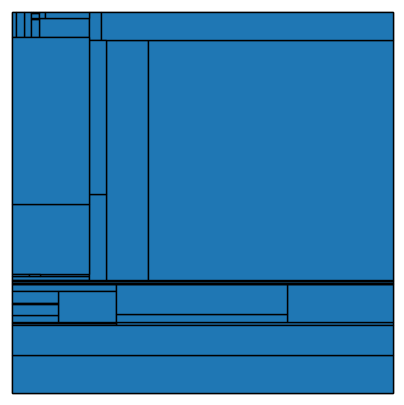

In [23]:
display_map(pre_rects)

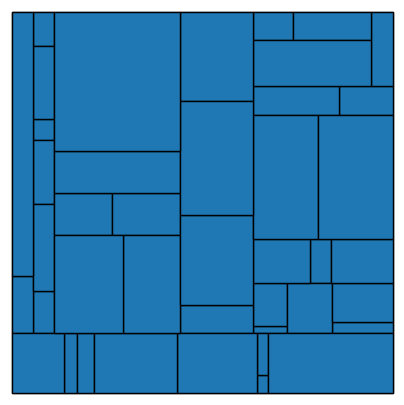

In [24]:
display_map(x_best)